In [1]:
# ============================================================
# CELL 1: Install packages
# ============================================================

# torchmetrics is used later for computing the FID score.
# torch-fidelity provides the Inception network used by TorchMetrics.

!pip install -q torchmetrics[image] torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 19.5 MB/s eta 0:00:00


In [2]:
# ============================================================
# CELL 2: Import required libraries
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import numpy as np

In [3]:
# ============================================================
# CELL 3: Device configuration and random seed
# ============================================================

# Use GPU if available.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Fixing random seeds makes results more reproducible.
torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Using device: cuda


In [4]:
# ============================================================
# CELL 4: Conditional GAN hyperparameters
# ============================================================

# Dimension of the random latent vector.
LATENT_DIM = 100

# MNIST images are 28 x 28.
IMAGE_SIZE = 28 * 28

LEARNING_RATE = 0.0002

# 10 is sufficient for a classroom demonstration.
# Increase this to 30-50 for better images.
NUM_EPOCHS = 25

# Number of Classes
NUM_CLASSES = 10

# Label Embedding Dimension
LABEL_EMBEDDING_DIM = 10

In [5]:
# ============================================================
# CELL 5: Download and prepare MNIST
# ============================================================

# Generator outputs will use Tanh().
#
# Tanh produces values in the range:
#
#       [-1, 1]
#
# Therefore we also convert the real MNIST images to [-1, 1].
#
# Original ToTensor() range:
#
#       [0, 1]
#
# Normalize(mean=0.5, std=0.5):
#
#       x_new = (x - 0.5) / 0.5
#
# converts:
#
#       0 -> -1
#       1 -> +1

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Number of training images:", len(train_dataset))
print("Number of batches:", len(train_loader))

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.70MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.27MB/s]

Number of training images: 60000
Number of batches: 469


In [6]:
# ============================================================
# CELL 6: Conditional GAN Generator
# ============================================================

class ConditionalGenerator(nn.Module):

    def __init__(
        self,
        latent_dim=100,
        num_classes=10,
        embedding_dim=10
    ):

        super().__init__()


        # Convert labels such as:
        #
        # 0, 1, 2, ..., 9
        #
        # into learnable vectors.
        #
        # Example:
        #
        # digit 7
        #
        #       ↓
        #
        # [0.32, -0.17, ..., 0.91]

        self.label_embedding = nn.Embedding(
            num_classes,
            embedding_dim
        )


        # Generator input consists of:
        #
        # noise + label embedding
        #
        # 100 + 10 = 110 dimensions

        input_dim = latent_dim + embedding_dim


        self.model = nn.Sequential(

            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 28 * 28),

            nn.Tanh()
        )


    def forward(self, noise, labels):

        # Convert labels into embeddings.
        label_vectors = self.label_embedding(labels)

        # Concatenate:
        #
        # random noise z
        #
        # +
        #
        # information about digit y

        x = torch.cat(
            [noise, label_vectors],
            dim=1
        )

        image = self.model(x)

        return image

In [7]:
# ============================================================
# CELL 7: Conditional GAN Discriminator
# ============================================================

class ConditionalDiscriminator(nn.Module):

    def __init__(
        self,
        num_classes=10,
        embedding_dim=10
    ):

        super().__init__()


        # The discriminator also needs to know
        # which class the image is supposed to represent.

        self.label_embedding = nn.Embedding(
            num_classes,
            embedding_dim
        )


        # Image = 784 values
        # Label embedding = 10 values
        #
        # Total input = 794

        input_dim = 28 * 28 + embedding_dim


        self.model = nn.Sequential(

            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1)
        )


    def forward(self, image, labels):

        # Obtain label representation.
        label_vectors = self.label_embedding(labels)

        # Concatenate image and label.
        x = torch.cat(
            [image, label_vectors],
            dim=1
        )

        prediction = self.model(x)

        return prediction

In [8]:
# ============================================================
# CELL 8: Initialize Conditional GAN
# ============================================================

cgan_G = ConditionalGenerator(
    latent_dim=LATENT_DIM,
    num_classes=NUM_CLASSES,
    embedding_dim=LABEL_EMBEDDING_DIM
).to(device)


cgan_D = ConditionalDiscriminator(
    num_classes=NUM_CLASSES,
    embedding_dim=LABEL_EMBEDDING_DIM
).to(device)


criterion = nn.BCEWithLogitsLoss()


optimizer_cG = optim.Adam(
    cgan_G.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)


optimizer_cD = optim.Adam(
    cgan_D.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

In [9]:
# ============================================================
# CELL 9: Train Conditional GAN
# ============================================================

cgan_G.train()
cgan_D.train()


for epoch in range(NUM_EPOCHS):

    running_d_loss = 0
    running_g_loss = 0


    for real_images, real_labels in train_loader:

        batch_size = real_images.size(0)

        real_images = real_images.to(device)

        real_labels = real_labels.to(device)


        # Flatten images for MLP.
        real_images = real_images.view(
            batch_size,
            -1
        )


        # ====================================================
        # STEP 1: TRAIN CONDITIONAL DISCRIMINATOR
        # ====================================================

        optimizer_cD.zero_grad()


        # Real image + correct label
        real_output = cgan_D(
            real_images,
            real_labels
        )


        real_targets = torch.ones(
            batch_size,
            1,
            device=device
        )


        loss_real = criterion(
            real_output,
            real_targets
        )


        # ----------------------------------------------------
        # Generate fake images
        # ----------------------------------------------------

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )


        # Choose random labels for the generated images.
        fake_labels = torch.randint(
            0,
            NUM_CLASSES,
            (batch_size,),
            device=device
        )


        fake_images = cgan_G(
            noise,
            fake_labels
        )


        # ----------------------------------------------------
        # Discriminator sees:
        #
        # generated image + generated image's requested label
        # ----------------------------------------------------

        fake_output = cgan_D(
            fake_images.detach(),
            fake_labels
        )


        fake_targets = torch.zeros(
            batch_size,
            1,
            device=device
        )


        loss_fake = criterion(
            fake_output,
            fake_targets
        )


        d_loss = loss_real + loss_fake

        d_loss.backward()

        optimizer_cD.step()


        # ====================================================
        # STEP 2: TRAIN CONDITIONAL GENERATOR
        # ====================================================

        optimizer_cG.zero_grad()


        fake_output = cgan_D(
            fake_images,
            fake_labels
        )


        # Generator wants generated examples
        # to be classified as real.
        generator_targets = torch.ones(
            batch_size,
            1,
            device=device
        )


        g_loss = criterion(
            fake_output,
            generator_targets
        )


        g_loss.backward()

        optimizer_cG.step()


        running_d_loss += d_loss.item()
        running_g_loss += g_loss.item()


    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"D Loss: {running_d_loss/len(train_loader):.4f} "
        f"G Loss: {running_g_loss/len(train_loader):.4f}"
    )

Epoch [1/25] D Loss: 1.1377 G Loss: 1.1647
Epoch [2/25] D Loss: 0.8999 G Loss: 1.9981
Epoch [3/25] D Loss: 0.8326 G Loss: 2.0085
Epoch [4/25] D Loss: 0.9419 G Loss: 1.7405
Epoch [5/25] D Loss: 0.8969 G Loss: 1.7534
Epoch [6/25] D Loss: 0.8682 G Loss: 1.9296
Epoch [7/25] D Loss: 0.8749 G Loss: 1.8197
Epoch [8/25] D Loss: 0.8910 G Loss: 1.8397
Epoch [9/25] D Loss: 0.9848 G Loss: 1.6184
Epoch [10/25] D Loss: 0.9795 G Loss: 1.5458
Epoch [11/25] D Loss: 1.0317 G Loss: 1.4274
Epoch [12/25] D Loss: 1.0657 G Loss: 1.3489
Epoch [13/25] D Loss: 1.1027 G Loss: 1.2650
Epoch [14/25] D Loss: 1.1272 G Loss: 1.2154
Epoch [15/25] D Loss: 1.1712 G Loss: 1.1374
Epoch [16/25] D Loss: 1.1799 G Loss: 1.1219
Epoch [17/25] D Loss: 1.1984 G Loss: 1.0760
Epoch [18/25] D Loss: 1.1950 G Loss: 1.0749
Epoch [19/25] D Loss: 1.2224 G Loss: 1.0447
Epoch [20/25] D Loss: 1.2049 G Loss: 1.0595
Epoch [21/25] D Loss: 1.2280 G Loss: 1.0271
Epoch [22/25] D Loss: 1.2230 G Loss: 1.0361
Epoch [23/25] D Loss: 1.2297 G Loss: 1.02

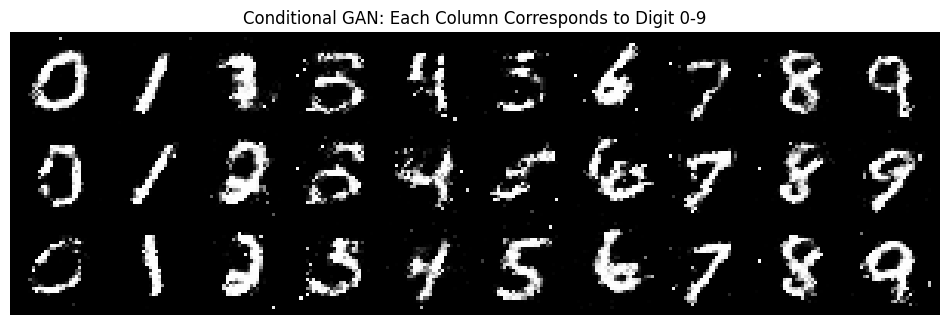

In [10]:
# ============================================================
# CELL 10: Generate specific digits
# ============================================================

cgan_G.eval()


# We explicitly ask the generator for:
#
# 0 1 2 3 4 5 6 7 8 9
#
# repeated three times.

requested_labels = torch.tensor(
    list(range(10)) * 3,
    device=device
)


with torch.no_grad():

    noise = torch.randn(
        len(requested_labels),
        LATENT_DIM,
        device=device
    )


    generated_images = cgan_G(
        noise,
        requested_labels
    )


    generated_images = generated_images.view(
        -1,
        1,
        28,
        28
    )


    generated_images = (
        generated_images + 1
    ) / 2


grid = make_grid(
    generated_images.cpu(),
    nrow=10
)


plt.figure(figsize=(12, 4))

plt.imshow(
    grid.permute(1, 2, 0)
)

plt.axis("off")

plt.title(
    "Conditional GAN: "
    "Each Column Corresponds to Digit 0-9"
)

plt.show()